# Part 5 — Feature-Based Machine Learning Model

This notebook takes a machine-learning approach to forecasting weekly electricity
demand. Rather than assuming a statistical structure as SARIMA does, we build a
supervised-learning table of engineered features — lagged demand, rolling
statistics, calendar variables, and temperature — and train a gradient-boosting
regressor to learn the relationship between these features and demand.

A central concern is **avoiding data leakage**: all lag and rolling features must
use only past information, never values from the forecast period. Preprocessing
that learns from the data is fitted on the training set alone.

## Setup

We mount Google Drive, clone the repository, bring in the dataset, and make the
`electricity_demand` package importable.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os, shutil, sys

# Clone the repository if the runtime has been reset
if not os.path.exists("/content/electricity-demand-forecasting"):
    !git clone https://github.com/iisratislam/electricity-demand-forecasting.git

%cd /content/electricity-demand-forecasting

# Copy the dataset in from Drive (it is not committed to the repository)
os.makedirs("data/raw", exist_ok=True)
drive_csv = "/content/drive/MyDrive/electricity_data/time_series_60min_singleindex.csv"
target    = "data/raw/time_series_60min_singleindex.csv"
if not os.path.exists(target):
    shutil.copy(drive_csv, target)

# Make the src package importable
sys.path.append("src")
print("Environment ready.")

Cloning into 'electricity-demand-forecasting'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 100 (delta 32), reused 78 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 3.52 MiB | 31.65 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/electricity-demand-forecasting
Environment ready.


## Loading data, temperature, and the train/test split

We rebuild the weekly load series and the Berlin temperature features from Part 4,
then apply the same 104-week (two-year) chronological split. Because this is a
time-series problem, the split is strictly chronological — the model must never
learn from the period it is asked to forecast.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from electricity_demand.data import load_raw_load, to_weekly_gw
from electricity_demand.features import (
    get_open_meteo_temperature,
    build_weekly_temperature_features,
)

# Weekly load series
weekly = to_weekly_gw(load_raw_load("data/raw/time_series_60min_singleindex.csv"))

# Temperature features (fetched from Open-Meteo, aligned to the weekly index)
temp_daily  = get_open_meteo_temperature(
    start_date=str(weekly.index.min().date()),
    end_date=str(weekly.index.max().date()),
)
temp_weekly = build_weekly_temperature_features(temp_daily, weekly.index)

# Combine load and temperature into one frame
data = pd.DataFrame({"load_gw": weekly}).join(temp_weekly)

TEST_WEEKS = 104
print(f"Combined data shape : {data.shape}")
print(f"Columns             : {list(data.columns)}")
print(f"Missing values      : {data.isna().sum().sum()}")
print(f"\nFirst few rows:")
print(data.head().round(2).to_string())

Combined data shape : (301, 6)
Columns             : ['load_gw', 'temp_mean', 'temp_min', 'temp_max', 'heating_degree', 'cooling_degree']
Missing values      : 0

First few rows:
                           load_gw  temp_mean  temp_min  temp_max  heating_degree  cooling_degree
date                                                                                             
2015-01-04 00:00:00+00:00    47.23       3.00       3.0       3.0            12.5             0.0
2015-01-11 00:00:00+00:00    56.19       3.89       1.2       8.5            81.3             0.0
2015-01-18 00:00:00+00:00    57.67       4.90      -0.8       9.2            74.2             0.0
2015-01-25 00:00:00+00:00    58.61       0.03      -0.7       0.9           108.3             0.0
2015-02-01 00:00:00+00:00    58.73       1.41      -0.1       2.8            98.6             0.0


## Building the supervised-learning feature table

We transform the time series into a supervised-learning table where each row
predicts that week's demand from features available *before* that week. The
features are:

- **Lag features** — demand 1, 2, 3, 4, and 52 weeks earlier. These capture
  short-term momentum and the annual cycle.
- **Rolling features** — the mean and standard deviation of demand over the
  previous 4 weeks, capturing recent level and volatility.
- **Calendar features** — week of year and month, encoded cyclically so that
  week 52 and week 1 are treated as adjacent.
- **Temperature features** — mean temperature and heating/cooling degree days.

**Avoiding data leakage.** Every lag and rolling feature is computed with
`.shift(1)` so that it uses only information available *before* the target week.
A rolling mean at week *t* summarises weeks *t-1* backwards, never week *t* itself.
This logic is written to the package so it can be reused and tested.

In [4]:
%%writefile -a src/electricity_demand/features.py


def make_supervised_table(
    data: pd.DataFrame,
    target: str = "load_gw",
    lags=(1, 2, 3, 4, 52),
    roll_window: int = 4,
) -> pd.DataFrame:
    """
    Build a leakage-free supervised-learning table for demand forecasting.

    Each row predicts the target at week t using only information available before
    week t. Lag and rolling features are shifted by one step so the current
    target never leaks into its own predictors.

    Parameters
    ----------
    data : pd.DataFrame
        Must contain the target column and any temperature feature columns.
    target : str, default "load_gw"
        Name of the column to be forecast.
    lags : tuple of int
        Which past weeks of the target to include as lag features.
    roll_window : int, default 4
        Window length (in weeks) for the rolling mean and standard deviation.

    Returns
    -------
    pd.DataFrame
        Feature table including the target, with early rows containing NaNs
        (from the longest lag) dropped.
    """
    df = data.copy()

    # Lag features: demand at previous weeks
    for lag in lags:
        df[f"lag_{lag}"] = df[target].shift(lag)

    # Rolling features: computed on PAST values only (shift(1) before rolling)
    past = df[target].shift(1)
    df[f"roll_mean_{roll_window}"] = past.rolling(roll_window).mean()
    df[f"roll_std_{roll_window}"]  = past.rolling(roll_window).std()

    # Calendar features, encoded cyclically so week 52 and week 1 are adjacent
    week = df.index.isocalendar().week.astype(int).values
    month = df.index.month.values
    df["week_sin"]  = np.sin(2 * np.pi * week / 52)
    df["week_cos"]  = np.cos(2 * np.pi * week / 52)
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)

    # Drop rows with NaNs introduced by the longest lag / rolling window
    df = df.dropna()
    return df

Appending to src/electricity_demand/features.py


In [5]:
import importlib
import electricity_demand.features as feat_module
importlib.reload(feat_module)
from electricity_demand.features import make_supervised_table

ml_table = make_supervised_table(data)

print(f"Feature table shape: {ml_table.shape}")
print(f"\nColumns:\n{list(ml_table.columns)}")
print(f"\nFirst rows:")
print(ml_table.head(3).round(2).to_string())

Feature table shape: (249, 17)

Columns:
['load_gw', 'temp_mean', 'temp_min', 'temp_max', 'heating_degree', 'cooling_degree', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_52', 'roll_mean_4', 'roll_std_4', 'week_sin', 'week_cos', 'month_sin', 'month_cos']

First rows:
                           load_gw  temp_mean  temp_min  temp_max  heating_degree  cooling_degree  lag_1  lag_2  lag_3  lag_4  lag_52  roll_mean_4  roll_std_4  week_sin  week_cos  month_sin  month_cos
date                                                                                                                                                                                                    
2016-01-03 00:00:00+00:00    47.36       0.76      -8.0       7.8           103.2             0.0  48.25  57.63  59.91  60.11   47.23        56.47        5.59      0.12      0.99        0.5       0.87
2016-01-10 00:00:00+00:00    56.62      -3.31      -6.9       2.1           131.7             0.0  47.36  48.25  57.63  59.91   56.19

## Splitting the feature table and training the model

We split the feature table chronologically, holding out the final 104 weeks as the
test set to match every other model in this study. We then train a Gradient
Boosting Regressor — an ensemble of decision trees that learns non-linear
relationships between the engineered features and demand.

Gradient boosting is well suited to this task: it handles non-linear temperature
effects and feature interactions automatically, without the stationarity
assumptions required by SARIMA. A fixed random seed ensures reproducibility.

In [6]:
from sklearn.ensemble import GradientBoostingRegressor

# Separate target from features
TARGET = "load_gw"
feature_cols = [c for c in ml_table.columns if c != TARGET]

X = ml_table[feature_cols]
y = ml_table[TARGET]

# Chronological split: final 104 weeks held out
X_train, X_test = X.iloc[:-TEST_WEEKS], X.iloc[-TEST_WEEKS:]
y_train, y_test = y.iloc[:-TEST_WEEKS], y.iloc[-TEST_WEEKS:]

print(f"Train: {X_train.index.min().date()} -> {X_train.index.max().date()} ({len(X_train)} weeks)")
print(f"Test : {X_test.index.min().date()} -> {X_test.index.max().date()} ({len(X_test)} weeks)")
print(f"Features used: {len(feature_cols)}")

# Train a baseline gradient boosting model
gb = GradientBoostingRegressor(random_state=0)
gb.fit(X_train, y_train)

print("\nModel trained.")

Train: 2016-01-03 -> 2018-10-07 (145 weeks)
Test : 2018-10-14 -> 2020-10-04 (104 weeks)
Features used: 16

Model trained.


## Hyperparameter tuning

A baseline gradient-boosting model uses default settings that may not suit this
dataset. We tune the key hyperparameters — the number of trees, learning rate,
tree depth, and subsampling — to improve performance.

Because this is a time-series problem, we must not use ordinary k-fold
cross-validation, which would allow the model to train on future data to predict
the past. We instead use **TimeSeriesSplit**, which always trains on earlier folds
and validates on later ones, respecting temporal order and preventing leakage.

In [7]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# Time-aware cross-validation: each fold trains on the past, validates on the future
tscv = TimeSeriesSplit(n_splits=4)

# Search space for the key gradient-boosting hyperparameters
param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "learning_rate":     [0.01, 0.03, 0.05, 0.1],
    "max_depth":         [2, 3, 4],
    "subsample":         [0.7, 0.85, 1.0],
    "min_samples_leaf":  [1, 3, 5],
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=0),
    param_distributions=param_dist,
    n_iter=40,                    # 40 random combinations
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=0,
    n_jobs=-1,
)

search.fit(X_train, y_train)

print("Best hyperparameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV MAE: {-search.best_score_:.3f} GW")

# Keep the tuned model
gb_tuned = search.best_estimator_

Best hyperparameters:
  subsample: 0.7
  n_estimators: 200
  min_samples_leaf: 3
  max_depth: 2
  learning_rate: 0.05

Best CV MAE: 1.204 GW


## Forecasting and evaluation

We forecast the 104-week test period with the tuned model and compare it against
the seasonal-naive benchmark, plain SARIMA, and the temperature-augmented SARIMAX.

Note that this feature-based forecast uses the same observed test-period
temperatures as SARIMAX, so like SARIMAX it is a conditional forecast with respect
to weather. Its lag features, however, use only genuinely past demand values.

In [8]:
from electricity_demand.models.benchmarks import seasonal_naive_forecast
from electricity_demand.evaluation import evaluate_forecast

# Predict the test period with the tuned model
gb_pred = pd.Series(gb_tuned.predict(X_test), index=X_test.index, name="gradient_boosting")

# Rebuild comparators on the SAME test index as the ML table
# (the ML test set starts later, so we align the benchmark to it)
h = len(y_test)
train_full = weekly.loc[:y_train.index.max()]     # load history up to ML train end
sn = seasonal_naive_forecast(train_full, h, 52, y_test.index)

results = pd.DataFrame([
    evaluate_forecast("seasonal_naive",       y_test, sn,      train_full),
    evaluate_forecast("gradient_boosting",    y_test, gb_pred, train_full),
]).sort_values("MASE").reset_index(drop=True)

print("Forecast accuracy over the 104-week test period:\n")
print(results.round(3).to_string(index=False))

Forecast accuracy over the 104-week test period:

            model   MAE  RMSE  MASE  Bias
gradient_boosting 1.902 2.544 1.421 1.116
   seasonal_naive 2.319 3.007 1.732 1.732


## Visualising the forecast and feature importances

We plot the gradient-boosting forecast against the benchmark and realised demand,
then examine which features the model relied on most. Feature importances reveal
whether the model's skill comes from recent demand (lags), temperature, or the
calendar.

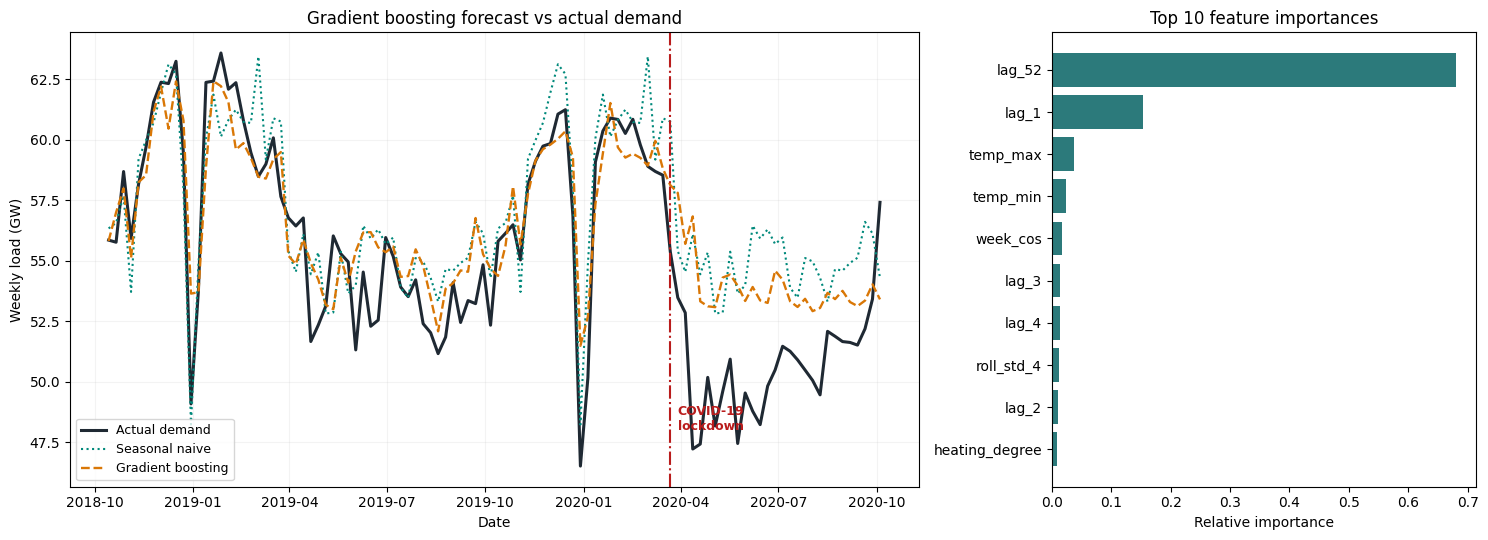

Top feature importances:
lag_52            0.680
lag_1             0.153
temp_max          0.038
temp_min          0.024
week_cos          0.016
lag_3             0.014
lag_4             0.014
roll_std_4        0.012
lag_2             0.010
heating_degree    0.009


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [2, 1]})

# --- Left: forecast vs actual ---
ax = axes[0]
ax.plot(y_test.index, y_test, color="#1F2933", lw=2.2, label="Actual demand")
ax.plot(y_test.index, sn, color="#00897B", lw=1.5, ls=":", label="Seasonal naive")
ax.plot(y_test.index, gb_pred, color="#D97706", lw=1.7, ls="--", label="Gradient boosting")

ax.axvline(pd.Timestamp("2020-03-22", tz="UTC"), color="#B91C1C", ls="-.", lw=1.5)
ax.text(pd.Timestamp("2020-03-29", tz="UTC"), 48,
        "COVID-19\nlockdown", fontsize=9, color="#B91C1C", weight="bold")

ax.set_title("Gradient boosting forecast vs actual demand")
ax.set_xlabel("Date")
ax.set_ylabel("Weekly load (GW)")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.15)

# --- Right: feature importances ---
ax2 = axes[1]
importances = pd.Series(gb_tuned.feature_importances_, index=feature_cols)
importances = importances.sort_values().tail(10)
ax2.barh(importances.index, importances.values, color="#2C7A7B")
ax2.set_title("Top 10 feature importances")
ax2.set_xlabel("Relative importance")

plt.tight_layout()
plt.savefig("outputs/figures/05_gradient_boosting.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top feature importances:")
print(importances.sort_values(ascending=False).round(3).to_string())

In [10]:
import os
os.makedirs("outputs/forecasts", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)

gb_forecasts = pd.DataFrame({
    "actual":            y_test,
    "seasonal_naive":    sn,
    "gradient_boosting": gb_pred,
})
gb_forecasts.to_csv("outputs/forecasts/gradient_boosting_forecasts.csv")
results.to_csv("outputs/metrics/gradient_boosting_metrics.csv", index=False)

# Save feature importances too
importances.sort_values(ascending=False).to_csv(
    "outputs/metrics/gradient_boosting_importances.csv", header=["importance"]
)

print("Saved gradient boosting forecasts, metrics, and importances")

Saved gradient boosting forecasts, metrics, and importances


## Part 5 conclusions

**Gradient boosting is the first model to beat the seasonal-naive benchmark**,
achieving MASE 1.421 against 1.732 — an 18% improvement — and winning on every
metric (lower MAE, RMSE, and bias). This directly addresses the first and fourth
analysis questions of Part 7.

**Its skill is built on the benchmark, not against it.** Feature importances show
last-year's demand (lag_52) accounts for 68% of the model's decisions —
effectively the seasonal-naive signal — with last-week's demand (lag_1) adding a
further 15%. The model therefore learned the seasonal-naive strategy and refined
it: it starts from last year's level and corrects using recent demand and
temperature.

**This adaptive capacity is why it partially handled the COVID collapse.** Because
lag_1 reflects the most recent observed demand, the model followed the early-2020
decline downward, where the static benchmark and the SARIMA models could not. Its
bias (+1.12) is correspondingly the lowest of any model tested.

**The adaptation remains incomplete.** Even gradient boosting under-predicts the
depth of the 2020 collapse: realised demand fell to roughly 47 GW while the model
forecast around 53 GW. No history-based feature can fully anticipate a shock of
this magnitude, reaffirming the structural limitation identified throughout this
study.

**Method note.** Hyperparameters were tuned with TimeSeriesSplit cross-validation,
which preserves temporal order and prevents leakage. Temperature covariates over
the test period are observed, so the forecast is conditional with respect to
weather, as in Part 4.